# Instructions

For **Training**: Ensure the CUB-200-2011 dataset and
61262-0.txt are accessible. Update zip_path/DATA_ROOT, TEXT_PATH, and CHECKPOINT_DIR to match your environment. Run all cells sequentially from top to bottom. Training takes approximately 1–2 hours with a colab A100 GPU. Checkpoints are saved automatically.

For **Testing** Only: Run the setup, import, and data loading cells, then skip all training cells which contain (skip when testing) at the top of the cell. upload the checkpoints (effnet_best.keras, custom_best.keras, transformer_best.keras) to the checkpoints directory that is created in the data loading . Run the evaluation cells to load the models and test. To evaluate on new data, run the interactive test cell at the end and provide the test folder path when prompted. The test folder should contain subfolders for each class. To test the LM, follow the instructions in the ineteractive funcation cell and enter your chosen seed.

# 1. Fine-Grained Classification:


In [1]:
# skip if not using google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, random, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import layers, Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"TF: {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

TF: 2.19.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import zipfile


# update this path to the path of the zip file
zip_path = '/content/drive/MyDrive/CUB_200_2011.zip'  # adjust this path as needed
extract_path = '/content/'

if not os.path.exists(os.path.join(extract_path, 'CUB_200_2011')): # check if file is there
    print(f"Unzipping {zip_path} to {extract_path}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Unzipping complete.")
    except FileNotFoundError:
        print(f"Error: The file '{zip_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
    except Exception as e:
        print(f"An error occurred during unzipping: {e}")
else:
    print(f"Dataset already extracted to {os.path.join(extract_path, 'CUB_200_2011')}")

Dataset already extracted to /content/CUB_200_2011


In [ ]:
DATA_ROOT = "/content/CUB_200_2011"
WORK_DIR = "/content/cub_organized"
# upload provided lm checkpoints to the below path when testing
CHECKPOINT_DIR = "/content/checkpoints"
RESULTS_DIR = "/content/results"
NUM_CLASSES = 200

for d in [CHECKPOINT_DIR, RESULTS_DIR]: os.makedirs(d, exist_ok=True)
assert os.path.isdir(DATA_ROOT) # check if dataset exists

---
## 1. Data Loading

In [5]:
%%time
def read_lines(path):
    with open(path) as f: return f.readlines()


# id for each image
images = {int(l.split()[0]): l.split()[1] for l in read_lines(f"{DATA_ROOT}/images.txt")}
# map image id to class labels
labels_map = {int(l.split()[0]): int(l.split()[1]) for l in read_lines(f"{DATA_ROOT}/image_class_labels.txt")}
# check if image is for testing or training, 1 train 0 test
splits = {int(l.split()[0]): int(l.split()[1]) for l in read_lines(f"{DATA_ROOT}/train_test_split.txt")}
# map class id to class name
class_names_raw = {int(l.split()[0]): l.split()[1] for l in read_lines(f"{DATA_ROOT}/classes.txt")}

# create two dictionaries for train and test
train_imgs, test_imgs = {}, {}
for idx, is_train in splits.items():
    src = os.path.join(DATA_ROOT, "images", images[idx]) # image path
    cls = class_names_raw[labels_map[idx]] # get class name for current image
    # add image path to either train_imgs or test_imgs based on the split
    (train_imgs if is_train else test_imgs).setdefault(cls, []).append(src)

# create working directory for organized data
random.seed(SEED) # seed for reproducibility in shuffling
for split in ['train', 'val', 'test']:
    os.makedirs(f"{WORK_DIR}/{split}", exist_ok=True) # Create main directories for each split

# train and validation directories
for cls, paths in train_imgs.items():
    # create class subdirectories within train and val splits
    for s in ['train', 'val']: os.makedirs(f"{WORK_DIR}/{s}/{cls}", exist_ok=True)
    shuffled = paths.copy(); random.shuffle(shuffled) # Shuffle image paths for train/val split
    val_n = max(1, int(len(shuffled) * 0.1)) # 1 or 10% imgs validation of each class
    # copy images to training directory under class subdir
    for p in shuffled[val_n:]:
        dst = f"{WORK_DIR}/train/{cls}/{os.path.basename(p)}"
        if not os.path.exists(dst): shutil.copy2(p, dst)
    # copy images to validation directory under class subdir
    for p in shuffled[:val_n]:
        dst = f"{WORK_DIR}/val/{cls}/{os.path.basename(p)}"
        if not os.path.exists(dst): shutil.copy2(p, dst)

# test Directory
for cls, paths in test_imgs.items():
    os.makedirs(f"{WORK_DIR}/test/{cls}", exist_ok=True) # Create class subdirectories within the test split
    for p in paths:
        dst = f"{WORK_DIR}/test/{cls}/{os.path.basename(p)}"
        if not os.path.exists(dst): shutil.copy2(p, dst)

# Summary
for s in ['train', 'val', 'test']:
    n = sum(len(os.listdir(f"{WORK_DIR}/{s}/{d}")) for d in os.listdir(f"{WORK_DIR}/{s}"))
    print(f"{s}: {n}")

train: 5400
val: 594
test: 5794
CPU times: user 80 ms, sys: 41 ms, total: 121 ms
Wall time: 121 ms


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

# 384×384 size for EfficientNet
IMG_SIZE_TL = (384, 384)
BATCH_SIZE_TL = 16

raw_train_ds_384 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/train", image_size=IMG_SIZE_TL, batch_size=BATCH_SIZE_TL,
    label_mode='int', shuffle=True, seed=SEED)
train_ds_384 = raw_train_ds_384.prefetch(AUTOTUNE)
val_ds_384 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/val", image_size=IMG_SIZE_TL, batch_size=BATCH_SIZE_TL,
    label_mode='int', shuffle=False).prefetch(AUTOTUNE)
test_ds_384 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/test", image_size=IMG_SIZE_TL, batch_size=BATCH_SIZE_TL,
    label_mode='int', shuffle=False).prefetch(AUTOTUNE)

# 224×224 for custom model
IMG_SIZE_CM = (224, 224)
BATCH_SIZE_CM = 32

raw_train_ds_224 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/train", image_size=IMG_SIZE_CM, batch_size=BATCH_SIZE_CM,
    label_mode='int', shuffle=True, seed=SEED)
train_ds_224 = raw_train_ds_224.prefetch(AUTOTUNE)
val_ds_224 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/val", image_size=IMG_SIZE_CM, batch_size=BATCH_SIZE_CM,
    label_mode='int', shuffle=False).prefetch(AUTOTUNE)
test_ds_224 = keras.utils.image_dataset_from_directory(
    f"{WORK_DIR}/test", image_size=IMG_SIZE_CM, batch_size=BATCH_SIZE_CM,
    label_mode='int', shuffle=False).prefetch(AUTOTUNE)

class_names = raw_train_ds_384.class_names
print(f"Classes: {len(class_names)}")
for imgs, _ in train_ds_384.take(1):
    print(f"384 batch: {imgs.shape}, range: [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]")
for imgs, _ in train_ds_224.take(1):
    print(f"224 batch: {imgs.shape}, range: [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]")

Found 5400 files belonging to 200 classes.
Found 594 files belonging to 200 classes.
Found 5794 files belonging to 200 classes.
Found 5400 files belonging to 200 classes.
Found 594 files belonging to 200 classes.
Found 5794 files belonging to 200 classes.
Classes: 200
384 batch: (16, 384, 384, 3), range: [0, 255]
224 batch: (32, 224, 224, 3), range: [0, 255]


In [ ]:
# Augmentation for 384x384 images (EfficientNet)
aug_384 = keras.Sequential([
    layers.RandomFlip('horizontal'),       # flip horizontally
    layers.RandomRotation(0.08),         # rotate
    layers.RandomZoom((-0.1, 0.1)),      # zoom in/out
    layers.RandomTranslation(0.08, 0.08), # move img horizontal and vertical
    layers.RandomBrightness(0.1),        # adjust brightness
    layers.RandomContrast(0.1),          # adjust contrast
], name='aug_384')

# Augmentation for 224x224 images (Custom Model)
aug_224 = keras.Sequential([
    layers.RandomFlip('horizontal'),       # flip horizontally
    layers.RandomRotation(0.05),         # rotate
    layers.RandomZoom((-0.05, 0.0)),     # zoom in
], name='aug_224')

# label smoothing to avoid overconfidence
def smooth(images, labels):
    # convert integer labels to one-hot encoding
    oh = tf.one_hot(labels, NUM_CLASSES)
    # 90% confidence in true label, 10% distributed among all classes
    return images, oh * 0.9 + 0.1 / NUM_CLASSES

# apply augmentation and label smoothing to the training datasets
train_ds_384_aug = train_ds_384.map(
    lambda x, y: (aug_384(x, training=True), y), num_parallel_calls=AUTOTUNE
).map(smooth, num_parallel_calls=AUTOTUNE)

# Apply only label smoothing to the validation dataset (no augmentation)
val_ds_384_oh = val_ds_384.map(smooth, num_parallel_calls=AUTOTUNE)

train_ds_224_aug = train_ds_224.map(
    lambda x, y: (aug_224(x, training=True), y), num_parallel_calls=AUTOTUNE
).map(smooth, num_parallel_calls=AUTOTUNE)

val_ds_224_oh = val_ds_224.map(smooth, num_parallel_calls=AUTOTUNE)

---
## 2. Model 1: EfficientNetV2 (Transfer Learning)

In [8]:
base = keras.applications.EfficientNetV2S(
    weights='imagenet', include_top=False, input_shape=(384, 384, 3)
)
inputs = keras.Input(shape=(384, 384, 3))
x = base(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_tl = Model(inputs, outputs, name='efficientnetv2s')
print(f"Total params: {model_tl.count_params():,}")

Total params: 20,587,560


In [9]:
# skip when testing
# Stage 1: Head only (256,200 parameters)
# optimiser: Adam, learning rate: 0.001 (fast), categorical crossentropy because of label smoothing
base.trainable = False
model_tl.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print(f"Stage 1 - trainable: {sum(tf.size(p).numpy() for p in model_tl.trainable_weights):,}") # sanity check

h1_s1 = model_tl.fit(
    train_ds_384_aug, validation_data=val_ds_384_oh, epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)]
)
print(f"Stage 1 best val acc: {max(h1_s1.history['val_accuracy'])*100:.2f}%")

Stage 1 - trainable: 256,200
Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 181s 338ms/step - accuracy: 0.1324 - loss: 4.5870 - val_accuracy: 0.4411 - val_loss: 2.8718
Epoch 2/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.4932 - loss: 2.7847 - val_accuracy: 0.5522 - val_loss: 2.4153
Epoch 3/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.6259 - loss: 2.3379 - val_accuracy: 0.5909 - val_loss: 2.2385
Epoch 4/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.6738 - loss: 2.1223 - val_accuracy: 0.6178 - val_loss: 2.1420
Epoch 5/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.7281 - loss: 1.9825 - val_accuracy: 0.6566 - val_loss: 2.0659
Epoch 6/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.7530 - loss: 1.8874 - val_accuracy: 0.6616 - val_loss: 2.0205
Epoch 7/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.7709 - loss: 1.8246 - val_accuracy: 0.6852 - val_loss: 1.9940
Epoch 8/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/ste

In [10]:
# skip when testing
# Stage 2: Fine-tune (20,587,560 parameters)
base.trainable = True
FT_EPOCHS = 60

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4, # lower rate and decays to alpha
    decay_steps=FT_EPOCHS * len(train_ds_384_aug),
    alpha=1e-6
)
model_tl.compile(optimizer=Adam(learning_rate=lr_schedule, clipnorm=1.0), # gradient clipping
                 loss='categorical_crossentropy', metrics=['accuracy'])

print(f"Stage 2 — LR: 1e-4 to 1e-6 (cosine), {FT_EPOCHS} epochs")
h1_s2 = model_tl.fit(
    train_ds_384_aug, validation_data=val_ds_384_oh, epochs=FT_EPOCHS,
    callbacks=[
        ModelCheckpoint(f"{CHECKPOINT_DIR}/effnet_best.keras",
                        monitor='val_accuracy', mode='max', save_best_only=True, verbose=1), # save best model
        EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1), # stop if no acc improvement for 12 epochs
    ]
)
print(f"Stage 2 best val acc: {max(h1_s2.history['val_accuracy'])*100:.2f}%")

Stage 2 — LR: 1e-4 to 1e-6 (cosine), 60 epochs
Epoch 1/60
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6690 - loss: 2.1503
Epoch 1: val_accuracy improved from -inf to 0.78620, saving model to /content/checkpoints/effnet_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 379s 527ms/step - accuracy: 0.6692 - loss: 2.1494 - val_accuracy: 0.7862 - val_loss: 1.6703
Epoch 2/60
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8922 - loss: 1.4124
Epoch 2: val_accuracy improved from 0.78620 to 0.80640, saving model to /content/checkpoints/effnet_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.8922 - loss: 1.4123 - val_accuracy: 0.8064 - val_loss: 1.6152
Epoch 3/60
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9394 - loss: 1.2597
Epoch 3: val_accuracy improved from 0.80640 to 0.81650, saving model to /content/checkpoints/effnet_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.9394 - loss: 1.2597 - val_accuracy: 0.8165 - val_loss: 1.564

---
## 3. Model 2: Custom CNN




In [ ]:
class ChannelAttention(layers.Layer):

    # Learn which feature channels are most important.

    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels                  # Number of input/output channels
        self.reduction = reduction                # Reduction ratio for bottleneck

        # Global Average Pooling: (H, W, C) to (C)
        self.gap = layers.GlobalAveragePooling2D()

        # fully connected layer 1 (bottleneck)
        # Reduces channel dimension to C // reduction
        self.fc1 = layers.Dense(channels // reduction, activation='relu')

        # fully connected layer 2
        # Expands back to original channel size and produces weights in [0,1]
        self.fc2 = layers.Dense(channels, activation='sigmoid')

        # Reshape to (1, 1, C)
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, x):
        # x shape: (batch, H, W, C)

        # Squeeze: global context vector per channel
        att = self.gap(x)                # (batch, C)

        # Bottleneck transformation
        att = self.fc1(att)              # (batch, C // reduction)

        # Channel importance weights
        att = self.fc2(att)              # (batch, C)

        # Reshape for broadcasting
        att = self.reshape(att)          # (batch, 1, 1, C)

        # Reweight original feature map
        return x * att                   # Channel-wise scaling

    def get_config(self):
        # saving and loading model
        return {
            **super().get_config(),
            'channels': self.channels,
            'reduction': self.reduction
        }


class MultiScaleConv(layers.Layer):
    #Parallel 3×3 and 5×5 convolutions to capture multi-scale features,
    # then 1×1 fusion and channel attention refinement.

    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        half = filters // 2              # Split filters equally between branches

        #  Fine-detail branch (3×3 convolution)
        self.conv3 = layers.Conv2D(
            half, 3, padding='same', use_bias=False
        )
        self.bn3 = layers.BatchNormalization()

        #  Broad-pattern branch (5×5 convolution)
        self.conv5 = layers.Conv2D(
            half, 5, padding='same', use_bias=False
        )
        self.bn5 = layers.BatchNormalization()

        #  Fusion layer (1×1 convolution)
        # Combines concatenated features into desired filter size
        self.fuse = layers.Conv2D(filters, 1, use_bias=False)
        self.bn_fuse = layers.BatchNormalization()

        # Channel attention to refine fused features
        self.att = ChannelAttention(filters)

    def call(self, x):
        # Branch 1: 3×3 conv → BN → ReLU
        b1 = tf.nn.relu(self.bn3(self.conv3(x)))

        # Branch 2: 5×5 conv → BN → ReLU
        b2 = tf.nn.relu(self.bn5(self.conv5(x)))

        # Concatenate along channel axis
        merged = tf.concat([b1, b2], axis=-1)

        # Fuse features with 1×1 conv → BN → ReLU
        out = tf.nn.relu(self.bn_fuse(self.fuse(merged)))

        # Apply channel attention
        return self.att(out)

    def get_config(self):
        # saving and loading model
        return {
            **super().get_config(),
            'filters': self.filters
        }


def build_custom_model(num_classes=200):
    """
    Build a custom CNN with:
    - Multi-scale convolution blocks
    - Channel attention
    - Progressive spatial downsampling
    """

    # Input image: 224×224 RGB
    inp = keras.Input(shape=(224, 224, 3))

    # Normalize pixel values [0,1]
    x = layers.Rescaling(1./255)(inp)


    # 224×224 → 112×112 (stride=2)
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 112×112 → 56×56
    x = layers.MaxPooling2D(2)(x)

    #  Stage 1: 56×56 → 28×28
    x = MultiScaleConv(64)(x)
    x = layers.Dropout(0.1)(x)           # light regularization
    x = layers.MaxPooling2D(2)(x)

    #  Stage 2: 28×28 → 14×14
    x = MultiScaleConv(128)(x)
    x = layers.Dropout(0.15)(x)
    x = layers.MaxPooling2D(2)(x)

    #  Stage 3: 14×14 → 7×7
    x = MultiScaleConv(256)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPooling2D(2)(x)

    #  Stage 4: 7×7
    x = MultiScaleConv(256)(x)

    # Classification Head
    # Global spatial aggregation
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer
    x = layers.Dense(256, activation='relu')(x)

    # heavy regularization
    x = layers.Dropout(0.5)(x)

    # Output layer with softmax
    out = layers.Dense(num_classes, activation='softmax')(x)

    # Build model
    return Model(inp, out, name='custom_cnn')



custom_model = build_custom_model(NUM_CLASSES)

# architecture summary
custom_model.summary(show_trainable=True)

# Print total parameter count
print(f"\nCustom model params: {custom_model.count_params():,}")


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_4 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d (Conv2D)             │ (None, 112, 112, 32)  │        864 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 112, 112, 32)  │        128 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ re_lu (ReLU)                │ (None, 112, 112, 32)  │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d               │ (None, 56, 56, 32)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ multi_scale_conv            │ (None, 56, 56, 64)    │     40,520 │   Y   │
│ (MultiScaleConv)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 56, 56, 64)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_1             │ (None, 28, 28, 64)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ multi_scale_conv_1          │ (None, 28, 28, 128)   │    160,912 │   Y   │
│ (MultiScaleConv)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 28, 28, 128)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_2             │ (None, 14, 14, 128)   │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ multi_scale_conv_2          │ (None, 14, 14, 256)   │    641,312 │   Y   │
│ (MultiScaleConv)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 14, 14, 256)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_3             │ (None, 7, 7, 256)     │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ multi_scale_conv_3          │ (None, 7, 7, 256)     │  1,198,368 │   Y   │
│ (MultiScaleConv)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_5  │ (None, 256)           │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_9 (Dense)             │ (None, 256)           │     65,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_4 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_10 (Dense)            │ (None, 200)           │     51,400 │   Y 

 Total params: 2,159,296 (8.24 MB)

 Trainable params: 2,156,416 (8.23 MB)

 Non-trainable params: 2,880 (11.25 KB)


Custom model params: 2,159,296


In [12]:
# skip when testing
custom_model.compile(
    # optimizer: Adam, learning rate: 0.001
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h2 = custom_model.fit(
    train_ds_224_aug, validation_data=val_ds_224_oh, epochs=70,
    callbacks=[
        ModelCheckpoint(f"{CHECKPOINT_DIR}/custom_best.keras",
                        monitor='val_accuracy', mode='max', save_best_only=True, verbose=1), # save best model
        # Reduce learning rate when loss does not improve for 5 epochs
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        # stop training when acc does not improve for 20 epochs
        EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1),
    ]
)
print(f"Best val acc: {max(h2.history['val_accuracy'])*100:.2f}%")

Epoch 1/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.0077 - loss: 5.3278
Epoch 1: val_accuracy improved from -inf to 0.00505, saving model to /content/checkpoints/custom_best.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 269ms/step - accuracy: 0.0077 - loss: 5.3277 - val_accuracy: 0.0051 - val_loss: 5.2640 - learning_rate: 0.0010
Epoch 2/70
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0081 - loss: 5.2068
Epoch 2: val_accuracy improved from 0.00505 to 0.00673, saving model to /content/checkpoints/custom_best.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.0081 - loss: 5.2065 - val_accuracy: 0.0067 - val_loss: 5.3069 - learning_rate: 0.0010
Epoch 3/70
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0192 - loss: 5.0752
Epoch 3: val_accuracy improved from 0.00673 to 0.01684, saving model to /content/checkpoints/custom_best.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.0192 - loss: 5.0743 - val_accuracy: 0.0168 - val_loss: 4.9966 - 

In [13]:
# skip when testing
# Save to Drive
drive_ckpt = os.path.join('/content/drive/MyDrive', "checkpoints")
os.makedirs(drive_ckpt, exist_ok=True)
for f in ["effnet_best.keras", "custom_best.keras"]:
    src = os.path.join(CHECKPOINT_DIR, f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(drive_ckpt, f))
        print(f"Saved {f}")

Saved effnet_best.keras
Saved custom_best.keras


---
## 4. Evaluation

In [ ]:
def evaluate(model, dataset, name):
    preds, truths = [], []
    for imgs, lbls in dataset:
        p = model.predict(imgs, verbose=0)
        preds.extend(np.argmax(p, axis=1))
        truths.extend(lbls.numpy() if len(lbls.shape)==1 else np.argmax(lbls.numpy(),1))
    yt, yp = np.array(truths), np.array(preds)
    m = {
        'Accuracy': accuracy_score(yt, yp) * 100,
        'Precision': precision_score(yt, yp, average='macro', zero_division=0) * 100,
        'Recall': recall_score(yt, yp, average='macro', zero_division=0) * 100,
        'F1 Score': f1_score(yt, yp, average='macro', zero_division=0) * 100,
    }
    print(f"\n{'='*50}\n{name} - Test Results\n{'='*50}")
    for k, v in m.items(): print(f"{k}: {v:.2f}%")
    return yt, yp, m

# calculate test acc for EfficientNet
best1 = keras.models.load_model(f"{CHECKPOINT_DIR}/effnet_best.keras")
# can comment below line when testing new data to save time
yt1, yp1, m1 = evaluate(best1, test_ds_384, "EfficientNetV2")

# Calculate test acc for custom model
best2 = keras.models.load_model(
    f"{CHECKPOINT_DIR}/custom_best.keras",
    custom_objects={'ChannelAttention': ChannelAttention, 'MultiScaleConv': MultiScaleConv}
)
# can comment below line when testing new data to save time
yt2, yp2, m2 = evaluate(best2, test_ds_224, "Custom CNN")


EfficientNetV2 - Test Results
Accuracy: 87.19%
Precision: 87.55%
Recall: 87.34%
F1 Score: 87.03%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'multi_scale_conv', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'multi_scale_conv_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'multi_scale_conv_2', however 


Custom Multi-Scale CNN - Test Results
Accuracy: 34.21%
Precision: 39.70%
Recall: 34.47%
F1 Score: 35.09%


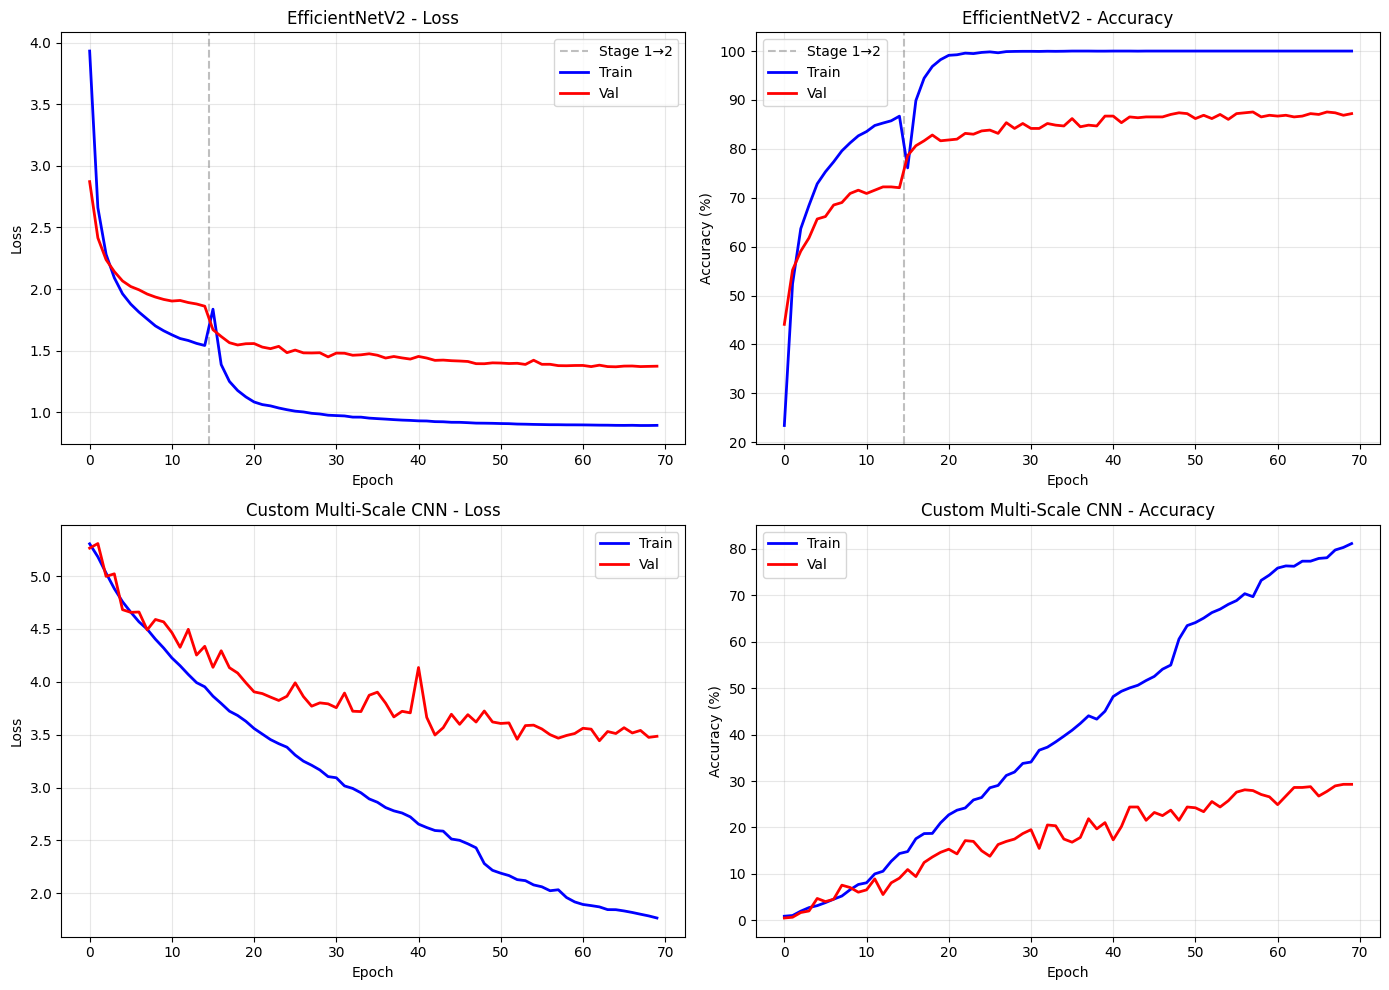

In [ ]:
# skip when testing
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# EfficientNet stage 1 + 2
e_loss = h1_s1.history['loss'] + h1_s2.history['loss']
e_vloss = h1_s1.history['val_loss'] + h1_s2.history['val_loss']
e_acc = h1_s1.history['accuracy'] + h1_s2.history['accuracy']
e_vacc = h1_s1.history['val_accuracy'] + h1_s2.history['val_accuracy']
s1_len = len(h1_s1.history['loss'])

axes[0,0].axvline(x=s1_len-0.5, color='gray', ls='--', alpha=0.5, label='Stage 1→2')
axes[0,0].plot(e_loss, 'b-', lw=2, label='Train')
axes[0,0].plot(e_vloss, 'r-', lw=2, label='Val')
axes[0,0].set(xlabel='Epoch', ylabel='Loss', title='EfficientNetV2 - Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].axvline(x=s1_len-0.5, color='gray', ls='--', alpha=0.5, label='Stage 1→2')
axes[0,1].plot([v*100 for v in e_acc], 'b-', lw=2, label='Train')
axes[0,1].plot([v*100 for v in e_vacc], 'r-', lw=2, label='Val')
axes[0,1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='EfficientNetV2 - Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(h2.history['loss'], 'b-', lw=2, label='Train')
axes[1,0].plot(h2.history['val_loss'], 'r-', lw=2, label='Val')
axes[1,0].set(xlabel='Epoch', ylabel='Loss', title='Custom Multi-Scale CNN - Loss')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot([v*100 for v in h2.history['accuracy']], 'b-', lw=2, label='Train')
axes[1,1].plot([v*100 for v in h2.history['val_accuracy']], 'r-', lw=2, label='Val')
axes[1,1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Custom Multi-Scale CNN - Accuracy')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()

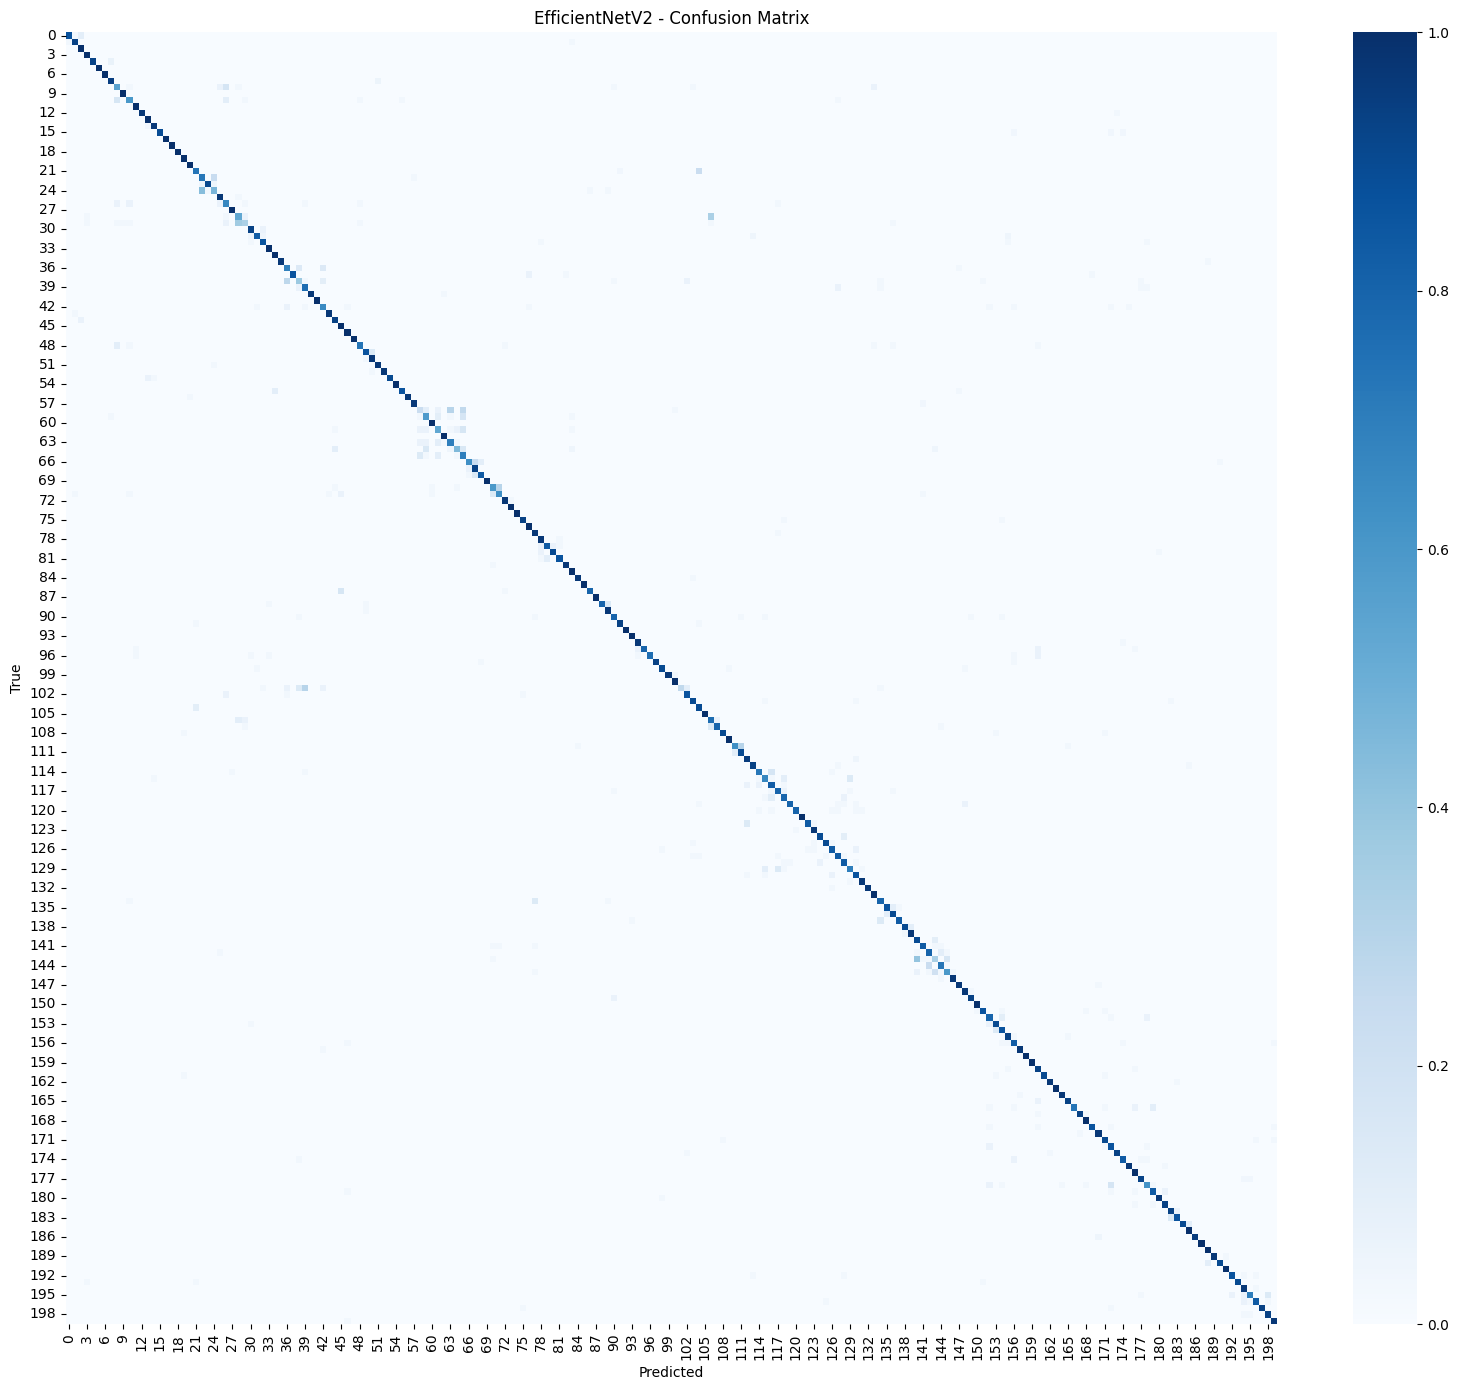

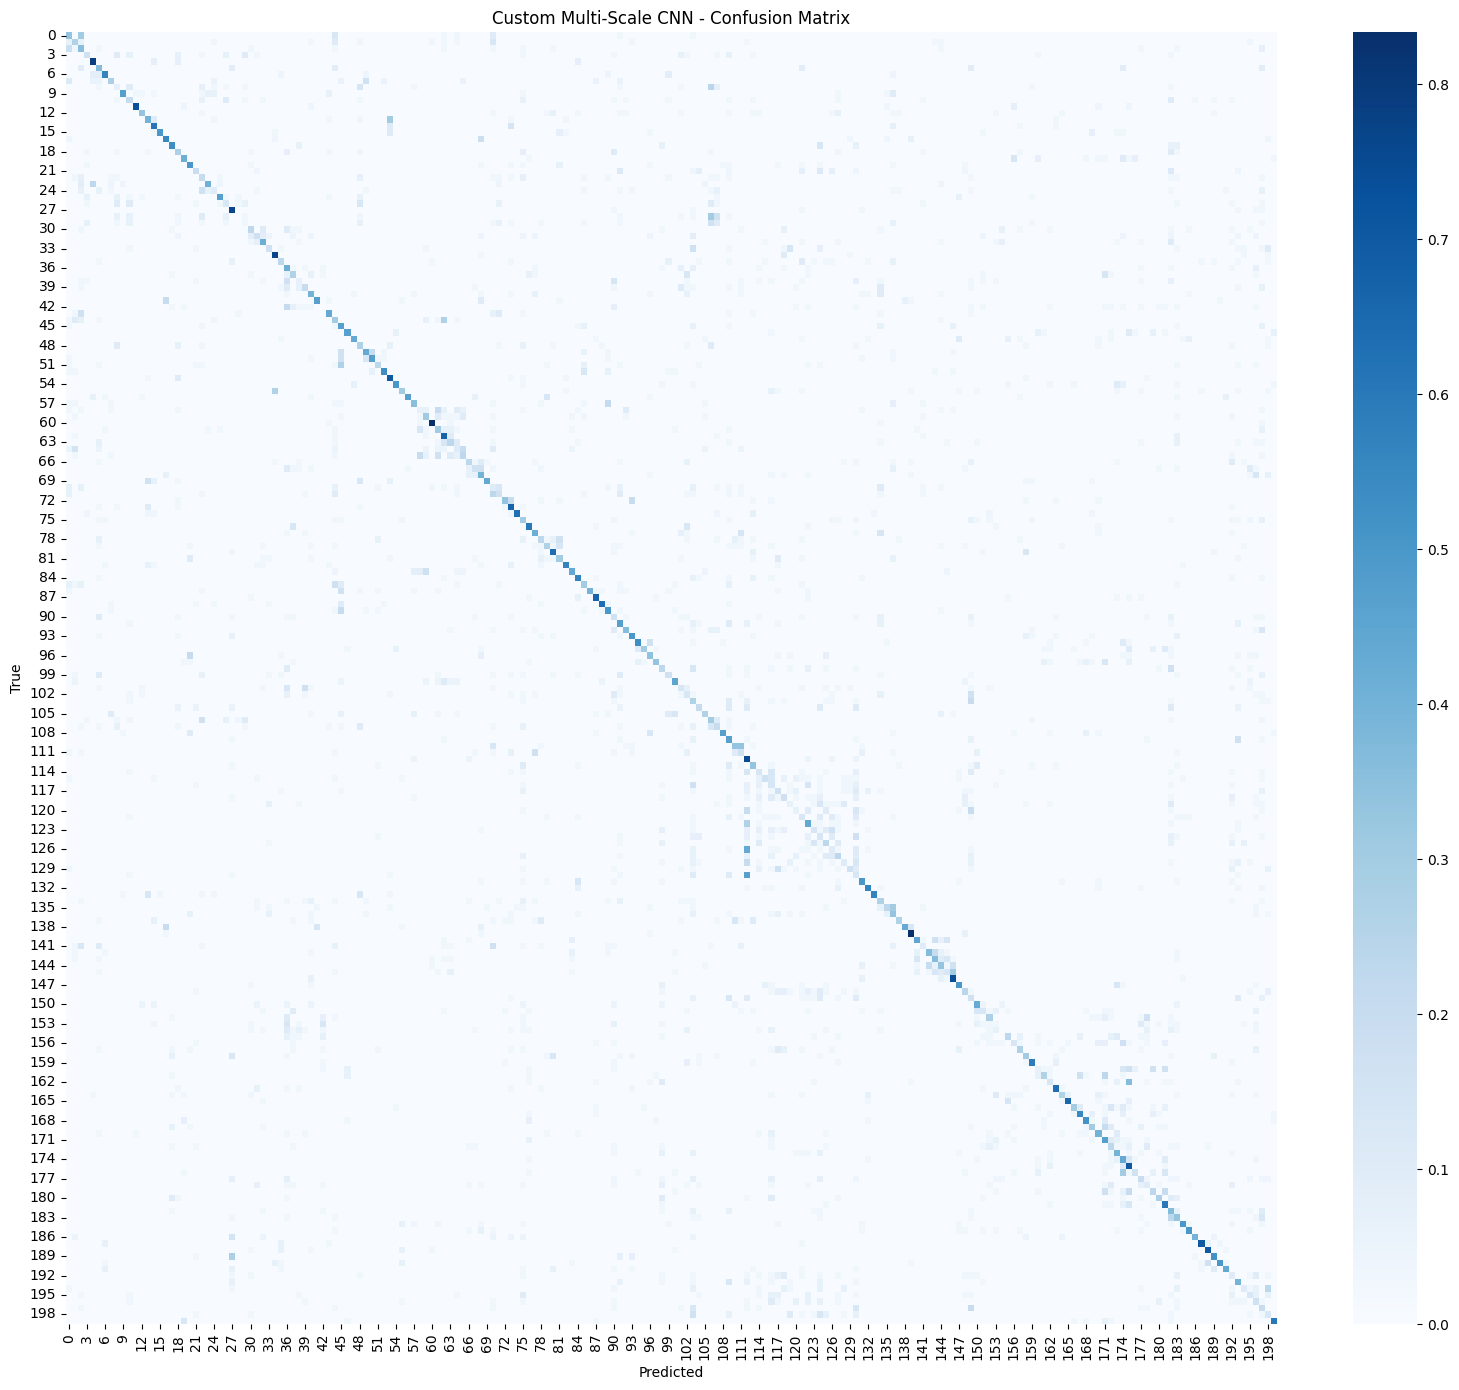

In [ ]:
# skip when testing
# Confusion matrices
for yt, yp, title in [(yt1, yp1, 'EfficientNetV2'), (yt2, yp2, 'Custom Multi-Scale CNN')]:
    cm = confusion_matrix(yt, yp)
    cm_n = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_n, cmap='Blues', cbar=True)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'{title} - Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{title.replace(' ','_')}_cm.png", dpi=150)
    plt.show()

In [17]:
# comparison
print("\n" + "="*65)
print("Final Results")
print("="*65)
print(f"{'Metric':<15} {'EfficientNet':>20} {'Custom CNN':>20}")
print("-"*65)
for k in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    print(f"{k:<15} {m1[k]:>19.2f}% {m2[k]:>19.2f}%")

results = {'efficientnet': m1, 'custom': m2}
for d in [RESULTS_DIR, os.path.join(os.path.dirname(DATA_ROOT), 'results')]:
    os.makedirs(d, exist_ok=True)
    with open(os.path.join(d, 'final_metrics.json'), 'w') as f:
        json.dump(results, f, indent=2)
print("Saved!")


FINAL RESULTS
Metric                  EfficientNet           Custom CNN
-----------------------------------------------------------------
Accuracy                      87.19%               34.21%
Precision                     87.55%               39.70%
Recall                        87.34%               34.47%
F1 Score                      87.03%               35.09%
Saved!


---
## 5. Evaluate on New Test Data

In [18]:
test_new = input("Do you want to test on a new folder? (yes/no): ").strip().lower()

if test_new in ['yes', 'y']:
    new_path = input("Enter the path to the test folder: ").strip()
    assert os.path.isdir(new_path), f"Folder not found: {new_path}"

    # Store the base dataset to access class_names, then prefetch
    raw_new_test_384 = keras.utils.image_dataset_from_directory(
        new_path, image_size=(384,384), batch_size=16,
        label_mode='int', shuffle=False)
    new_test_384 = raw_new_test_384.prefetch(AUTOTUNE)

    raw_new_test_224 = keras.utils.image_dataset_from_directory(
        new_path, image_size=(224,224), batch_size=32,
        label_mode='int', shuffle=False)
    new_test_224 = raw_new_test_224.prefetch(AUTOTUNE)

    # Use the class_names from one of the raw datasets or the global class_names
    print(f"\nLoaded {len(raw_new_test_384.class_names)} classes from: {new_path}")

    yt1_new, yp1_new, m1_new = evaluate(best1, new_test_384, "EfficientNetV2 (New Test)")
    yt2_new, yp2_new, m2_new = evaluate(best2, new_test_224, "Custom CNN (New Test)")


    print("\n" + "="*65)
    print("NEW TEST DATA RESULTS")
    print("="*65)
    print(f"{'Metric':<15} {'EfficientNetV2':>20} {'Custom CNN':>20}")
    print("-"*65)
    for k in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
        print(f"{k:<15} {m1_new[k]:>19.2f}% {m2_new[k]:>19.2f}%")
else:
    print("Skipping new test data evaluation.")

Do you want to test on a new folder? (yes/no): yes
Enter the path to the test folder: /content/cub_organized/test
Found 5794 files belonging to 200 classes.
Found 5794 files belonging to 200 classes.

Loaded 200 classes from: /content/cub_organized/test

EfficientNetV2 (New Test) - Test Results
Accuracy: 87.19%
Precision: 87.55%
Recall: 87.34%
F1 Score: 87.03%

Custom MS-CNN (New Test) - Test Results
Accuracy: 34.21%
Precision: 39.70%
Recall: 34.47%
F1 Score: 35.09%

NEW TEST DATA RESULTS
Metric                EfficientNetV2           Custom CNN
-----------------------------------------------------------------
Accuracy                      87.19%               34.21%
Precision                     87.55%               39.70%
Recall                        87.34%               34.47%
F1 Score                      87.03%               35.09%


The dataset was split using the train/test text file, with 10% of training data used for validation .

Images were resized to (384×384) for the EfficientNetV2 model and 224×224 for the custom model. Data augmentation included random horizontal flips, rotation, zoom, translation, and brightness/contrast variation. Label smoothing (0.1) was applied to prevent overconfident predictions. These decisions were made by iterative experimentation, where we found that moderate augmentation performed best, heavier augmentation caused underfitting on our small dataset, while too little augmentation led to overfitting.

EfficientNetV2 which was pre trained on ImageNet dataset with a two stage training strategy is used. Stage 1 froze the backbone and trained only the classification head (GlobalAveragePooling, Dropout(0.3), Dense(200)) for 15 epochs at learning rate of (1e-3), which created stable head weights. Stage 2 unfroze all layers and was fine tuned with cosine decay (LR from 1e-4 to 1e-6) and gradient clipping (clipnorm=1.0) to avoid gradient exploding for 60 epochs.

We designed a custom architecture featuring parallel 3×3 and 5×5 convolutions to capture features at multiple scales (fine details like beak shape and broader patterns like wing shape), followed by channel attention to weight feature importance. The model uses four progressive stages (64 --> 128 --> 256 --> 256 filters) with increasing dropout (0.1 to 0.5) and is lightweight to reduce overfitting. It was trained with Adam (LR of 1e-3), ReduceLROnPlateau, and early stopping (patience=20) for up to 100 epochs.

The large gap between the two models shows the power of transfer learning where the first model learned from millions of ImageNet images, while the custom model must learn everything from approximately 5,400 training images.

--------
# Language Model

Small GPT style Transformer decoder trained on *Poirot Investigates* book.
- GloVe 100d embeddings + positional encoding
- 4 Transformer blocks, 4 attention heads
- Causal self-attention to only look at previous words

In [19]:
import os, re, json, random, zipfile, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, Model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from collections import Counter

print(f"TF: {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TF: 2.19.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# configuration
TEXT_PATH = "/content/61262-0.txt"  # <-- update text file path
# upload provided lm checkpoints to the below path when testing 
CHECKPOINT_DIR = "/content/lm_checkpoints"
RESULTS_DIR = "/content/lm_results"
GLOVE_DIR = "/content/glove"

for d in [CHECKPOINT_DIR, RESULTS_DIR, GLOVE_DIR]:
    os.makedirs(d, exist_ok=True)
assert os.path.exists(TEXT_PATH), f"Text file not found: {TEXT_PATH}"

In [ ]:
%%time
# download GloVe embedding
glove_path = f"{GLOVE_DIR}/glove.6B.100d.txt"
if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings (~800MB compressed)...")
    !wget -q -P {GLOVE_DIR} https://nlp.stanford.edu/data/glove.6B.zip
    with zipfile.ZipFile(f"{GLOVE_DIR}/glove.6B.zip", 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    os.remove(f"{GLOVE_DIR}/glove.6B.zip")
    print("Done!")
else:
    print("GloVe already downloaded.")

# load glove embedding word vector
glove = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype='float32')
print(f"Loaded {len(glove):,} GloVe vectors (100d)")

Done!
Loaded 400,000 GloVe vectors (100d)
CPU times: user 11 s, sys: 545 ms, total: 11.5 s
Wall time: 2min 52s


In [22]:
# Load and clean text
with open(TEXT_PATH, 'r', encoding='utf-8') as f:
    raw = f.read()

# remove header/footer
start = raw.find('I was standing at the window')
end = raw.find('THE END', start)
text = raw[start:end].strip()

# normalize all whitespaces to a single space
text = text.replace('\r\n', ' ').replace('\n', ' ')
text = re.sub(r'  +', ' ', text)

# seperate punctuations as individual tokens
text = re.sub(r'([.,!?;:\'"\-])', r' \1 ', text)
text = re.sub(r'\s+', ' ', text).strip().lower()

tokens = text.split()
print(f"Total tokens: {len(tokens):,}")
print(f"Preview: {' '.join(tokens[:40])}")

Total tokens: 63,882
Preview: i was standing at the window of poirot’s rooms looking out idly on the street below . “that’s queer , ” i ejaculated suddenly beneath my breath . “what is , _mon ami_ ? ” asked poirot placidly , from


In [23]:
# Build vocabulary
MIN_FREQ = 3
counts = Counter(tokens)

# keep only words with freq >= 3 and in GLOVE
vocab_words = [w for w, c in counts.most_common()
               if c >= MIN_FREQ and (w in glove or w in '.,!?;:\'"-')]

vocab = ['<PAD>'] + vocab_words
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)

# Filter tokens to vocabulary
filtered = [t for t in tokens if t in word2idx]
encoded = [word2idx[t] for t in filtered]

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Tokens kept: {len(filtered):,} / {len(tokens):,} ({len(filtered)/len(tokens)*100:.1f}%)")

Vocabulary size: 1980
Tokens kept: 55,778 / 63,882 (87.3%)


In [24]:
# embedding matrix from GloVe
EMBED_DIM = 100  # match GloVe dimension

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, idx in word2idx.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
    else:
        embedding_matrix[idx] = np.random.uniform(-0.05, 0.05, EMBED_DIM)

in_glove = sum(1 for w in vocab_words if w in glove)
print(f"Words with GloVe vectors: {in_glove}/{len(vocab_words)}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words with GloVe vectors: 1979/1979
Embedding matrix shape: (1980, 100)


In [25]:
SEQ_LEN = 32
BATCH_SIZE = 64

# Create sequences: input = 32 words, target = next word
seqs, targets = [], []
for i in range(0, len(encoded) - SEQ_LEN):
    seqs.append(encoded[i:i+SEQ_LEN])
    targets.append(encoded[i+SEQ_LEN])

X = np.array(seqs) # input word sequence
y = np.array(targets) # output next word

# 90/10 train/val split
split = int(len(X) * 0.9)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# shuffle for training, batches of 64, prefetch for faster training
train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
# no shuffle for validation
val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

print(f"Train: {len(X_train):,} sequences")
print(f"Val:   {len(X_val):,} sequences")
print(f"Sequence length: {SEQ_LEN}")

Train: 50,171 sequences
Val:   5,575 sequences
Sequence length: 32


In [ ]:
# Transformer decoder block with causal self-attention
class TransformerBlock(layers.Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        # Store config values (needed for saving/loading the model)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout

        # Multi-head self-attention layer
        # key_dim is per-head dimension (embed_dim split across heads)
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        # Position-wise feed-forward network (FFN)
        # Expands dimension then GELU then projects back to embed_dim
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dense(embed_dim),
        ])

        # Layer normalization applied after each residual connection
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)

        # Dropout for regularization
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        # x shape: (batch_size, seq_len, embed_dim)

        #  Create causal mask 
        # Prevent each token from attending to future tokens
        seq_len = tf.shape(x)[1]
        causal_mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len)), -1, 0
        )
        causal_mask = tf.cast(causal_mask, tf.bool)

        # Multi-head self-attention 
        # Query, Key, and Value are all x (self-attention)
        attn_output = self.att(
            x, x,
            attention_mask=causal_mask
        )

        # Apply dropout during training
        attn_output = self.drop1(attn_output, training=training)

        # Residual connection and layer normalization
        x = self.ln1(x + attn_output)

        #  feed forward network 
        ffn_output = self.ffn(x)

        # Apply dropout
        ffn_output = self.drop2(ffn_output, training=training)

        # Residual connection + layer normalization
        return self.ln2(x + ffn_output)

    def get_config(self):
        # enable model (saving/loading)
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout': self.dropout_rate
        })
        return config


In [27]:
# build model
NUM_HEADS = 4
FF_DIM = 256
NUM_BLOCKS = 4
DROPOUT = 0.2

# Input
inp = keras.Input(shape=(SEQ_LEN,), name='input')

# Word embeddings (GloVe)
token_emb = layers.Embedding(
    VOCAB_SIZE, EMBED_DIM,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True, name='word_embedding'
)(inp)

# positional embeddings (learned)
positions = tf.range(SEQ_LEN)
pos_emb = layers.Embedding(SEQ_LEN, EMBED_DIM, name='position_embedding')(positions)

#  word + position
x = token_emb + pos_emb
x = layers.Dropout(DROPOUT)(x)

# 4 transfomer blocks
for i in range(NUM_BLOCKS):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT, name=f'transformer_block_{i}')(x)

# last token output (next word)
x = x[:, -1, :]

# Output head
x = layers.Dense(EMBED_DIM, activation='gelu', name='output_dense')(x)
x = layers.Dropout(DROPOUT)(x)
out = layers.Dense(VOCAB_SIZE, name='output_logits')(x)

model = Model(inp, out, name='mini_gpt')
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "mini_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embedding (Embedding)      │ (None, 32, 100)        │       198,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 32, 100)        │        92,356 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 32, 100)        │        92,356 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 32, 100)        │        92,356 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 32, 100)        │        92,356 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_logits (Dense)           │ (None, 1980)           │       199,980 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777,504 (2.97 MB)

 Trainable params: 777,504 (2.97 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 777,504


In [28]:
# skip when testing
EPOCHS = 20

# optimiser: adam, lr: 5e-4, gradient clipping, loss: Sparse Categorical Crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f"Training for up to {EPOCHS} epochs...")

history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=[
        ModelCheckpoint(f"{CHECKPOINT_DIR}/transformer_best.keras",
                        monitor='val_loss', mode='min',
                        save_best_only=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=1),
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
    ]
)

Training for up to 20 epochs...
Epoch 1/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0865 - loss: 5.8135
Epoch 1: val_loss improved from inf to 5.23243, saving model to /content/lm_checkpoints/transformer_best.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.0865 - loss: 5.8130 - val_accuracy: 0.1387 - val_loss: 5.2324 - learning_rate: 5.0000e-04
Epoch 2/20
781/784 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1433 - loss: 4.9396
Epoch 2: val_loss improved from 5.23243 to 5.10004, saving model to /content/lm_checkpoints/transformer_best.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1433 - loss: 4.9395 - val_accuracy: 0.1552 - val_loss: 5.1000 - learning_rate: 5.0000e-04
Epoch 3/20
778/784 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1537 - loss: 4.7501
Epoch 3: val_loss improved from 5.10004 to 5.04193, saving model to /content/lm_checkpoints/transformer_best.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1537 - loss: 4.7501 -

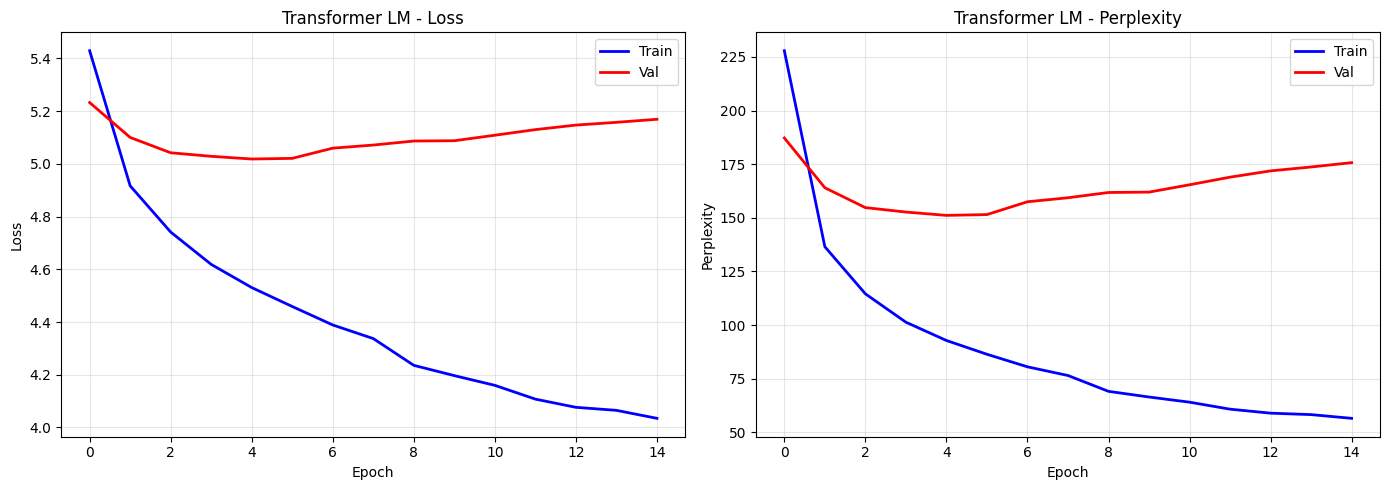


Best val loss: 5.0183
Best val perplexity: 151.15


In [ ]:
# skip when testing
# Plot training curves
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

a1.plot(history.history['loss'], 'b-', lw=2, label='Train')
a1.plot(history.history['val_loss'], 'r-', lw=2, label='Val')
a1.set(xlabel='Epoch', ylabel='Loss', title='Transformer LM - Loss')
a1.legend(); a1.grid(alpha=0.3)

tp = [np.exp(min(l, 10)) for l in history.history['loss']]
vp = [np.exp(min(l, 10)) for l in history.history['val_loss']]
a2.plot(tp, 'b-', lw=2, label='Train')
a2.plot(vp, 'r-', lw=2, label='Val')
a2.set(xlabel='Epoch', ylabel='Perplexity', title='Transformer LM - Perplexity')
a2.legend(); a2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/transformer_curves.png", dpi=150)
plt.show()

best_loss = min(history.history['val_loss'])
print(f"\nBest val loss: {best_loss:.4f}")
print(f"Best val perplexity: {np.exp(best_loss):.2f}")

In [30]:
# skip when testing
# Save checkpoints to Drive
drive_ckpt = os.path.join('/content/drive/MyDrive', "lm_checkpoints")
os.makedirs(drive_ckpt, exist_ok=True)
src = f"{CHECKPOINT_DIR}/transformer_best.keras"
if os.path.exists(src):
    shutil.copy2(src, os.path.join(drive_ckpt, "transformer_best.keras"))

vocab_data = {
    'word2idx': word2idx,
    'idx2word': {int(k): v for k, v in idx2word.items()},
    'vocab_size': VOCAB_SIZE,
    'seq_len': SEQ_LEN,
}
with open(os.path.join(drive_ckpt, 'vocab.json'), 'w') as f:
    json.dump(vocab_data, f)
print(f"Saved to {drive_ckpt}")

Saved to /content/drive/MyDrive/lm_checkpoints


In [31]:
# Load best model: try checkpoint first when testing, otherwise use in-memory model
ckpt_path = f"{CHECKPOINT_DIR}/transformer_best.keras"
if os.path.exists(ckpt_path):
    print(f"Loading best model from {ckpt_path}")
    best_model = keras.models.load_model(ckpt_path, custom_objects={'TransformerBlock': TransformerBlock})
else:
    print("No checkpoint found, using in-memory model")
    best_model = model


def generate(seed_text, num_words=80, temperature=0.7,
             top_p=0.9, repetition_penalty=1.3):
    """Generate text with nucleus sampling + repetition penalty.

    Args:
        seed_text: Starting text (e.g. 'Poirot looked at')
        num_words: Number of words to generate
        temperature: 0.3=focused, 0.7=balanced, 1.0=creative
        top_p: Nucleus sampling (0.9 = sample from top 90% probability)
        repetition_penalty: >1 reduces repetition (1.3 works well)
    """
    # Tokenize seed text
    seed_clean = re.sub(r'([.,!?;])', r' \1 ', seed_text).lower().split()
    current = [word2idx[t] for t in seed_clean if t in word2idx]
    if not current:
        current = [word2idx.get('the', 1)]

    output_words = [idx2word[i] for i in current]
    recent = list(current[-15:])

    for _ in range(num_words):
        # Pad/truncate to SEQ_LEN
        if len(current) < SEQ_LEN:
            padded = [0] * (SEQ_LEN - len(current)) + current
        else:
            padded = current[-SEQ_LEN:]

        # Get model prediction (raw logits)
        logits = best_model.predict(np.array([padded]), verbose=0)[0]

        # Apply temperature
        logits = logits / temperature

        # Apply repetition penalty to recently used words
        for idx in set(recent):
            if logits[idx] > 0:
                logits[idx] /= repetition_penalty
            else:
                logits[idx] *= repetition_penalty

        # Never predict PAD token
        logits[0] = -1e10

        # Convert to probabilities (numerically stable softmax)
        probs = np.exp(logits - np.max(logits))
        probs /= probs.sum()

        # Nucleus (top-p) sampling
        sorted_idx = np.argsort(probs)[::-1]
        cumsum = np.cumsum(probs[sorted_idx])
        cutoff = np.searchsorted(cumsum, top_p) + 1
        top_idx = sorted_idx[:cutoff]
        top_probs = probs[top_idx]
        top_probs /= top_probs.sum()

        # Sample next word
        next_idx = np.random.choice(top_idx, p=top_probs)

        output_words.append(idx2word[next_idx])
        current.append(next_idx)
        recent.append(next_idx)
        if len(recent) > 20:
            recent.pop(0)

    # Format output nicely
    result = ' '.join(output_words)
    result = re.sub(r" ([.,!?;:])", r"\1", result)       # Attach punctuation
    result = re.sub(r'([.!?])\s+(\w)',                     # Capitalise after sentences
                    lambda m: m.group(1) + ' ' + m.group(2).upper(), result)
    if result:
        result = result[0].upper() + result[1:]
    return result

Loading best model from /content/lm_checkpoints/transformer_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_2', how

In [32]:
# text gen with different temps
seed = "Poirot smiled and said"
print("=" * 70)
print(f'SEED TEXT: "{seed}"')
print("=" * 70)

for temp, label in [(0.3, 'Conservative'), (0.7, 'Balanced'), (1.0, 'Creative')]:
    print(f"\n--- {label} (temperature={temp}) ---")
    print(generate(seed, num_words=80, temperature=temp))

SEED TEXT: "Poirot smiled and said"

--- Conservative (temperature=0.3) ---
Poirot smiled and said poirot, and the house. ” i was a little. It was a little, and a few minutes, and the door. The same time, and the of the case of the police. The window. He was a few minutes later, and in the door, the door, and the police. I said poirot, and the of the other. He was a little. It is to be

--- Balanced (temperature=0.7) ---
Poirot smiled and said. ” was here, with the latter? ” i shall see the other, then and known, that he had his hand. ” she was a woman? ” i pray you are no way? ” i said poirot, but to me the time? ” the case. The other. It is of england with a little particular little accuracy? You have been about a man. It, but i

--- Creative (temperature=1.0) ---
Poirot smiled and said it arrived at him as then before in a matter to turn here about my part? ” that only given, ” i took the safe with him to be a careful of the evening by a touch. ”.. And really does i did it was about

In [33]:
# other seeds gen
seeds = [
    "the detective examined",
    "it was a dark",
    "my dear hastings",
    "the murder had been",
    "she looked at him and",
]

print("=" * 70)
print("MULTIPLE SEEDS (temperature=0.7)")
print("=" * 70)
for s in seeds:
    print(f'\n--- "{s}" ---')
    print(generate(s, num_words=60, temperature=0.7))

MULTIPLE SEEDS (temperature=0.7)

--- "the detective examined" ---
The detective examined his wife. He had a quarter of the good. Was about the door. I got with the case of his wife of the big question, and the room. She was a flash the american. He handed in england? ” i am gone. Did not have have been useless? ” he has

--- "it was a dark" ---
It was a dark. They was known, that the door was a minute his revolver. She was not a gesture of this kind of his head. The sea, and i heard to be, with a idea? ” said the man, if a recent to his head. The way was a moment of his own.

--- "my dear hastings" ---
My dear hastings., the morning: you? ” i reminded him that he have a fit of a sheet. He has been very moment in the police affair? ”, and then is a bit to our things! ” i see, but there would know it. You! You have not have find some.

--- "the murder had been" ---
The murder had been no, who returned, and, and a idea, mr. We heard a sigh of the prime minister to the moment. He was that

In [39]:
# interactive
# run the cell to input own text seed for testing
def interactive():
    print("Interactive text generation (type 'quit' to stop)")
    while True:
        seed = input("\nEnter seed text: ")
        if seed.lower() == 'quit':
            break
        try:
            n = int(input("Words to generate (default 80): ") or 80)
        except:
            n = 80
        try:
            t = float(input("Temperature 0.3-1.2 (default 0.7): ") or 0.7)
        except:
            t = 0.7
        print("\nGenerated text:")
        print(generate(seed, num_words=n, temperature=t))

# uncomment the line below to use interactive mode
#interactive()

Interactive text generation (type 'quit' to stop)

Enter seed text: Deduce, Poirot, from the following facts! Here is a young lady,
Words to generate (default 80): 
Temperature 0.3-1.2 (default 0.7): 

Generated text:
, poirot, from the following facts! Here is a young lady, i have just off to all. ” is to be ill - night, as you.., i say not to the flat? But the valet, with a good finger - morrow and with me of a man. ”. It was. As i believe, my friend and put to my return on the housekeeper. You see all for a little wonderful and i come by her husband, ” i

Enter seed text: quit


In [35]:
# ChatGPT comparison
our_seed = "Poirot smiled and said"
our_output = generate(our_seed, num_words=100, temperature=0.7)

print("=" * 70)
print("OUR TRANSFORMER MODEL OUTPUT")
print("=" * 70)
print(our_output)



#   ChatGPTs out when prompted:
#   "Continue this text in the style of Agatha Christie's Poirot stories:
#   'Poirot smiled and said' — write about 100 words."


chatgpt_output = """Poirot smiled and said, “You perceive, my friend, only the surface of things.
It is the little grey cells that must be consulted.” He adjusted the fall of his immaculate tie
and cast a reflective glance about the drawing room, where the fire burned low and shadows
clung to the corners like guilty secrets. “Everyone imagines the tragedy occurred at half past nine.
Everyone is quite wrong.” His finger tapped the mantel with delicate precision.
“The truth, as always, is modest. It whispers. One has only to arrange the facts with order and
method—and the murderer, naturellement, arranges himself before us.”"""

print("\n" + "=" * 70)
print("CHATGPT OUTPUT")
print("=" * 70)
print(chatgpt_output)

OUR TRANSFORMER MODEL OUTPUT
Poirot smiled and said poirot. ”, and by a duplicate idea. The diamond of an time, i asked us me, at his own. ” said poirot, but i are not not have left the man with some moment that he said miss marvell. ”. ” i do you? ” the other! ” said poirot, but he was shown to tell him. But he could have been brought her by the revolver was a little good. She had disappeared, and i would have not, to see? ” i

CHATGPT OUTPUT
Poirot smiled and said, “You perceive, my friend, only the surface of things.
It is the little grey cells that must be consulted.” He adjusted the fall of his immaculate tie
and cast a reflective glance about the drawing room, where the fire burned low and shadows
clung to the corners like guilty secrets. “Everyone imagines the tragedy occurred at half past nine.
Everyone is quite wrong.” His finger tapped the mantel with delicate precision.
“The truth, as always, is modest. It whispers. One has only to arrange the facts with order and
method—and

The training data consists of Agatha Christie's book “Poirot Investigates" which contains around 60,000 words.


Text was cleaned by converting to lowercase, normalising whitespaces, and tokenising words.

A vocabulary was built by filtering out words appearing fewer than 3 times and words that do not appear in the GloVe embedding as well, ensuring every word has a meaningful pre trained representation. The final vocabulary contains 1980 words. Training sequences of length 32 were created using a sliding window approach, where each sequence predicts the next word.

We implemented a transformer decoder with 4 Transformer blocks, each containing 4 head causal self attention with residual connections and layer normalisation. The embedding layer was initialised with GloVe 100 dimensional pre trained vectors since our training data is too small for the model to learn word meanings from scratch. GloVe provides word relationships learned from 6 billion words of text. Positional embeddings encode word order within each sequence.

The model was trained using Adam with ReduceLROnPlateau and SparseCategoricalCrossentropy. Dropout was applied within attention and feed forward layers and Early stopping based on validation loss. These hyperparameters were determined through experimentation, where we tested LSTM vs Transformer architectures, various sequence lengths (15 to 32), embedding dimensions, and found that the Transformer with GloVe and sequence length of 32 produced the most coherent output.

Best validation perplexity resulted was approximately 151. Example outputs with prompt "Poirot smiled and said" and with different temperatures (creativity levels):
**Temperature 0.7**: _"was here, with the latter? i shall see the other, then and known, that he had his hand. she was a woman? i pray you are no way? i said poirot, but to me the time?"_
**Temperature 1.0**: _"it closely. you and quite found here the two longer down! ah, then saw, his money was on his own old man was something of that he had and to the lock with a beautiful."_

The model tries to capture Christie's style in dialogue structure and detective themes but produces imperfect grammar, which can be expected given the small training size. Comparing it to ChatGPT which produces fluent accurate sentences, these findings demonstrate that size of data, number of parameters, and the architecture scale is what separates our model from human comprehensible text generation.
